# **Sistema Inteligente de Triagem em Pronto-Socorro**
---

### *Trabalho Final - IA Aplicada*






> Gabriel Garcia Colares - 581964


> Rômulo Emanuel Marinho Barbosa - 579586



> João Gabriel Aquino Ferreira - 582424







# **Módulo 1: Redes Bayesianas**

In [ ]:
!pip install pgmpy
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import math
import heapq
import random


In [ ]:
'''Definindo a estrutura da rede (causas -> efeito)'''

modelo_triagem = DiscreteBayesianNetwork([
    ('Febre', 'Gravidade'),
    ('SaturacaoO2', 'Gravidade'),
    ('PressaoArterial', 'Gravidade'),
    ('FrequenciaCardiaca', 'Gravidade'),
    ('NivelDor', 'Gravidade'),
    ('IdadeDoencaCronica', 'Gravidade')
])

print("Nós da rede:", modelo_triagem.nodes())
print("Arestas estruturadas:", modelo_triagem.edges())

Nós da rede: ['Febre', 'Gravidade', 'SaturacaoO2', 'PressaoArterial', 'FrequenciaCardiaca', 'NivelDor', 'IdadeDoencaCronica']
Arestas estruturadas: [('Febre', 'Gravidade'), ('SaturacaoO2', 'Gravidade'), ('PressaoArterial', 'Gravidade'), ('FrequenciaCardiaca', 'Gravidade'), ('NivelDor', 'Gravidade'), ('IdadeDoencaCronica', 'Gravidade')]


In [ ]:
def visualizar_rede(modelo, titulo="Rede Bayesiana"):
    plt.figure(figsize=(12, 6))
    pos = nx.circular_layout(modelo)
    nx.draw_networkx_nodes(modelo, pos, node_color='lightblue', node_size=2200)
    nx.draw_networkx_edges(modelo, pos, edge_color='gray', arrows=True,
                           arrowstyle='-|>', arrowsize=20, node_size=2200)
    nx.draw_networkx_labels(modelo, pos, font_size=12, font_weight='bold')
    plt.title(titulo, fontsize=16, fontweight='bold')
    plt.axis('off'); plt.tight_layout(); plt.show()

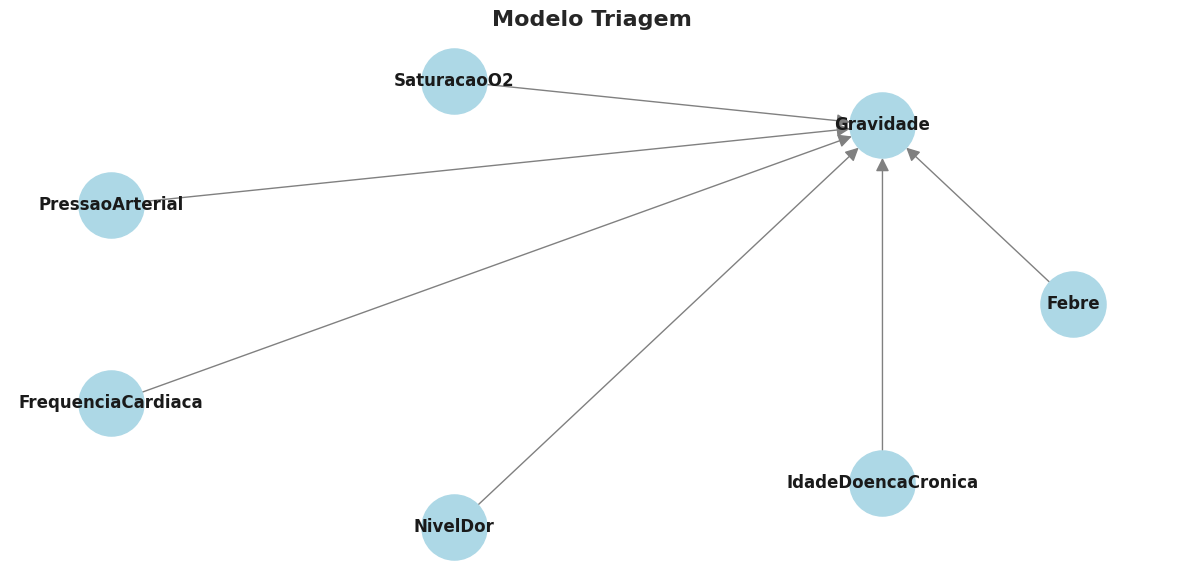

In [ ]:
visualizar_rede(modelo_triagem, "Modelo Triagem")

In [ ]:
'''Baseado na Dica Prática do Trabalho:
Se não encontrarem dados reais, simulem uma base de 50–100 pacientes com
distribuições plausíveis. Isso é aceitável desde que documentado no relatório.'''


'''Fixando a semente aleatória para o resultado ser sempre o mesmo ao testar'''
np.random.seed(42)
num_pacientes = 1000

'''
Gerando os dados vitais (sintomas) de forma aleatória com proporções realistas
Ex: A maioria chega com saturação normal, mas uma minoria chega crítica
'''

saturacao = np.random.choice(['Normal_Alta', 'Reduzida', 'Critica'], size=num_pacientes, p=[0.80, 0.15, 0.05])
dor = np.random.choice(['Leve_Moderada', 'Intensa'], size=num_pacientes, p=[0.7, 0.3])
febre = np.random.choice(['Sem_Febre_Leve', 'Alta'], size=num_pacientes, p=[0.6, 0.4])
freq_cardiaca = np.random.choice(['Normal', 'Alterada'], size=num_pacientes, p=[0.8, 0.2])
pressao = np.random.choice(['Normal', 'Anormal_Choque'], size=num_pacientes, p=[0.85, 0.15])
idade_doenca = np.random.choice(['Saudavel_Jovem', 'Idoso_Comorbidade'], size=num_pacientes, p=[0.6, 0.4])

'''Criando o DataFrame'''
df_pacientes = pd.DataFrame({
    'SaturacaoO2': saturacao,
    'NivelDor': dor,
    'Febre': febre,
    'FrequenciaCardiaca': freq_cardiaca,
    'PressaoArterial': pressao,
    'IdadeDoencaCronica': idade_doenca
})

def calcular_gravidade(row):
    '''
    Lógica para definir a "Gravidade" baseada no Protocolo de Manchester

    Calcula a classificação de gravidade do paciente utilizando um sistema de pontuação
    inspirado no Protocolo de Manchester. Sintomas que apresentam risco imediato à vida
    (como saturação de O2 crítica e choque) recebem pesos numéricos maiores. Essa abordagem
    garante que a triagem reflita urgências humanas reais, servindo como base causal e
    confiável para o treinamento da Rede Bayesiana.

    Parâmetros:
    row (pd.Series): Linha do DataFrame contendo os sinais vitais simulados do paciente.

    Retorna:
    str: Classificação categórica da gravidade ('Alta', 'Media' ou 'Baixa').
    '''
    pontos = 0
    '''Atribuindo pesos aos sintomas (situações mais críticas pesam mais)'''
    if row['SaturacaoO2'] == 'Critica': pontos += 3
    elif row['SaturacaoO2'] == 'Reduzida': pontos += 1

    if row['PressaoArterial'] == 'Anormal_Choque': pontos += 2
    if row['NivelDor'] == 'Intensa': pontos += 1
    if row['Febre'] == 'Alta': pontos += 1
    if row['FrequenciaCardiaca'] == 'Alterada': pontos += 1
    if row['IdadeDoencaCronica'] == 'Idoso_Comorbidade': pontos += 1

    '''Classificando a gravidade de acordo com a pontuação'''
    if pontos >= 4:
        return 'Alta'
    elif pontos >= 2:
        return 'Media'
    else:
        return 'Baixa'

'''Aplicando a regra para criar a coluna alvo'''
df_pacientes['Gravidade'] = df_pacientes.apply(calcular_gravidade, axis=1)

'''Visualizando os primeiros pacientes e a distribuição'''
display((df_pacientes.head()))
print("\nDistribuição de Gravidade no PS Sintético:")
display(df_pacientes['Gravidade'].value_counts(normalize=True).round(3))

,SaturacaoO2,NivelDor,Febre,FrequenciaCardiaca,PressaoArterial,IdadeDoencaCronica,Gravidade
0,Normal_Alta,Leve_Moderada,Sem_Febre_Leve,Normal,Normal,Saudavel_Jovem,Baixa
1,Critica,Leve_Moderada,Sem_Febre_Leve,Normal,Normal,Saudavel_Jovem,Media
2,Normal_Alta,Intensa,Alta,Normal,Normal,Idoso_Comorbidade,Media
3,Normal_Alta,Intensa,Sem_Febre_Leve,Normal,Normal,Saudavel_Jovem,Baixa
4,Normal_Alta,Intensa,Sem_Febre_Leve,Normal,Normal,Idoso_Comorbidade,Media



Distribuição de Gravidade no PS Sintético:


,proportion
Gravidade,
Media,0.457
Baixa,0.432
Alta,0.111


In [ ]:
'''Fazendo a rede "aprender" as Tabelas de Probabilidade (CPTs) com os nossos dados'''
modelo_triagem.fit(df_pacientes)

'''Validando se as probabilidades somam 1.0 corretamente'''
print("Modelo válido?", modelo_triagem.check_model())

'''Criando o motor de inferência'''
inferencia_triagem = VariableElimination(modelo_triagem)

'''
Testando a inferência (O output exato que o Módulo 2 vai consumir)
Exemplo do PDF: febre alta, saturação 91% (Reduzida), pressão baixa (Anormal_Choque),
dor nível 8 (Intensa), idoso/diabético (Idoso_Comorbidade).
'''
print("\nEstimativa de Gravidade para o Paciente Teste:")
resultado = inferencia_triagem.query(
    variables=['Gravidade'],
    evidence={
        'Febre': 'Alta',
        'SaturacaoO2': 'Reduzida',
        'PressaoArterial': 'Anormal_Choque',
        'NivelDor': 'Intensa',
        'IdadeDoencaCronica': 'Idoso_Comorbidade'
        #obs: não passamos a Frequência Cardíaca mas a rede vai inferir mesmo assim.
    }
)

print(resultado)

Modelo válido? True

Estimativa de Gravidade para o Paciente Teste:
+------------------+------------------+
| Gravidade        |   phi(Gravidade) |
+==================+==================+
| Gravidade(Alta)  |           0.8693 |
+------------------+------------------+
| Gravidade(Baixa) |           0.0653 |
+------------------+------------------+
| Gravidade(Media) |           0.0653 |
+------------------+------------------+


# **Módulo 2: O algoritmo A***

In [ ]:
class Paciente:
    def __init__(self, id_paciente, p_alta, tempo_esperando):
        self.id_paciente = id_paciente
        self.p_alta = p_alta
        self.tempo_esperando = tempo_esperando
        self.tau = 30.0 #constante de tolerância de tempo (ex: 30 minutos)

    def calcular_risco_atual(self):
        '''Usando a função exponencial: risco = P(alta) * e^(tempo/tau)'''
        f_tempo = math.exp(self.tempo_esperando / self.tau)
        return self.p_alta * f_tempo

    def __repr__(self):
        return f"Paciente(id={self.id_paciente}, p_alta={self.p_alta:.2f}, tempo={self.tempo_esperando}min, risco={self.calcular_risco_atual():.2f})"

'''Nossa fila de testes corrigida'''
fila_inicial = [
    Paciente(id_paciente="Ana", p_alta=0.85, tempo_esperando=10),
    Paciente(id_paciente="Bruno", p_alta=0.60, tempo_esperando=30),
    Paciente(id_paciente="Carla", p_alta=0.20, tempo_esperando=5),
    Paciente(id_paciente="Diego", p_alta=0.45, tempo_esperando=20),
    Paciente(id_paciente="Elena", p_alta=0.10, tempo_esperando=45)
]

print("Fila inicial com Risco Exponencial:")
for p in fila_inicial:
    print(p)

Fila inicial com Risco Exponencial:
Paciente(id=Ana, p_alta=0.85, tempo=10min, risco=1.19)
Paciente(id=Bruno, p_alta=0.60, tempo=30min, risco=1.63)
Paciente(id=Carla, p_alta=0.20, tempo=5min, risco=0.24)
Paciente(id=Diego, p_alta=0.45, tempo=20min, risco=0.88)
Paciente(id=Elena, p_alta=0.10, tempo=45min, risco=0.45)


In [ ]:
class EstadoFila:
    def __init__(self, pacientes_restantes, ordem_atendimento, custo_g, tempo_atual):
        self.pacientes_restantes = pacientes_restantes #Lista de objetos Paciente
        self.ordem_atendimento = ordem_atendimento     # Lista com os IDs de quem já foi atendido
        self.custo_g = custo_g                         # Risco acumulado até este momento
        self.tempo_atual = tempo_atual                 # Tempo no relógio do hospital

    def heuristica_h(self):
        '''definido no PDF do trabalho: h(n) = soma dos riscos atuais de todos na fila'''
        soma_riscos = sum(p.calcular_risco_atual() for p in self.pacientes_restantes)
        return soma_riscos

    def custo_f(self):
        '''A* usa f(n) = g(n) + h(n)'''
        return self.custo_g + self.heuristica_h()

    def gerar_sucessores(self, tempo_por_atendimento=10):
        '''
        Gera as ramificações (estados sucessores) na árvore de busca do algoritmo A*.
        A base matemática desta função está no cálculo do custo g(n): ao simular o
        atendimento de um paciente, o sistema penaliza essa escolha somando o risco de
        deterioração de *todos* os outros pacientes que continuam aguardando na fila.
        Isso garante que casos moderados não sejam negligenciados, pois o tempo de espera
        funciona como um fator exponencial que eleva o risco coletivo.

        Parâmetros:
        tempo_por_atendimento (int): Minutos consumidos por cada triagem/atendimento (padrão: 10).

        Retorna:
        list: Lista de objetos EstadoFila representando as próximas configurações possíveis da fila.
        '''

        sucessores = []
        '''Para cada paciente que ainda está na fila, simulamos o atendimento dele'''
        for i, paciente_escolhido in enumerate(self.pacientes_restantes):
            '''
            Qual seria o custo g extra que a fila vai sofrer enquanto esse paciente é atendido?
            O PDF diz: O custo de uma ação é o risco acumulado de TODOS que continuam esperando
            '''
            risco_da_espera = sum(p.calcular_risco_atual() for p in self.pacientes_restantes if p.id_paciente != paciente_escolhido.id_paciente)
            novo_custo_g = self.custo_g + risco_da_espera

            '''Atualizamos o tempo de quem sobrou na fila'''
            nova_fila = []
            for p in self.pacientes_restantes:
                if p.id_paciente != paciente_escolhido.id_paciente:
                    '''Criamos uma cópia do paciente com o tempo de espera atualizado (+10 min)'''
                    novo_paciente = Paciente(p.id_paciente, p.p_alta, p.tempo_esperando + tempo_por_atendimento)
                    nova_fila.append(novo_paciente)

            '''Registramos a ordem de atendimento'''
            nova_ordem = self.ordem_atendimento + [paciente_escolhido.id_paciente]

            '''Criamos o novo nó (estado) e adicionamos aos sucessores'''
            novo_estado = EstadoFila(nova_fila, nova_ordem, novo_custo_g, self.tempo_atual + tempo_por_atendimento)
            sucessores.append(novo_estado)

        return sucessores

    '''Métodos necessários para a fila de prioridade do A* funcionar (ele precisa comparar os nós)'''
    def __lt__(self, outro):
        return self.custo_f() < outro.custo_f()

In [ ]:
def simular_estrategia_basica(fila_inicial, estrategia="FIFO"):
    '''Criamos uma cópia profunda da fila para não alterar os dados originais'''
    import copy
    pacientes_restantes = copy.deepcopy(fila_inicial)

    ordem_atendimento = []
    custo_total = 0.0
    tempo_por_atendimento = 10

    while pacientes_restantes:
        '''ordenando a fila'''
        if estrategia == "FIFO":
            pacientes_restantes = pacientes_ordenados = sorted(pacientes_restantes, key=lambda p: p.tempo_esperando, reverse=True)
        elif estrategia == "Gulosa":
            pacientes_restantes = pacientes_ordenados = sorted(pacientes_restantes, key=lambda p: p.p_alta, reverse=True)

        '''escolhendo o primeiro e retirando da fila'''
        paciente_escolhido = pacientes_restantes.pop(0)
        ordem_atendimento.append(paciente_escolhido.id_paciente)

        '''atualizando o custo (o risco de quem ficou esperando)'''
        risco_da_espera = sum(p.calcular_risco_atual() for p in pacientes_restantes)
        custo_total += risco_da_espera

        '''atualiando o tempo de quem ficou'''
        for p in pacientes_restantes:
            p.tempo_esperando += tempo_por_atendimento

    return ordem_atendimento, custo_total

'''estando as estratégias'''
ordem_fifo, custo_fifo = simular_estrategia_basica(fila_inicial, "FIFO")
ordem_gulosa, custo_gulosa = simular_estrategia_basica(fila_inicial, "Gulosa")

print(f"Estratégia FIFO: Ordem {ordem_fifo} | Custo Total: {custo_fifo:.2f}")
print(f"Estratégia Gulosa: Ordem {ordem_gulosa} | Custo Total: {custo_gulosa:.2f}")

Estratégia FIFO: Ordem ['Elena', 'Bruno', 'Diego', 'Ana', 'Carla'] | Custo Total: 10.55
Estratégia Gulosa: Ordem ['Ana', 'Bruno', 'Diego', 'Carla', 'Elena'] | Custo Total: 7.92


In [ ]:
def busca_a_estrela(fila_inicial):
    import copy
    '''Criamos o estado raiz (A fila do jeito que está agora)'''
    estado_inicial = EstadoFila(
        pacientes_restantes=copy.deepcopy(fila_inicial),
        ordem_atendimento=[],
        custo_g=0.0,
        tempo_atual=0
    )
    '''
    Inicializamos a nossa fronteira de busca usando a biblioteca heapq
    O heapq sempre vai manter o nó com menor custo_f() na frente
    '''

    fronteira = []
    heapq.heappush(fronteira, estado_inicial)

    nos_explorados = 0

    '''O Loop de busca'''
    while fronteira:
        '''Puxamos o estado mais promissor da fila de prioridade'''
        estado_atual = heapq.heappop(fronteira)
        nos_explorados += 1

        '''Teste de objetivo: A fila esvaziou?'''
        if not estado_atual.pacientes_restantes:
            return estado_atual.ordem_atendimento, estado_atual.custo_g, nos_explorados

        '''Caso contrário, geramos as ramificações (simulando atender cada um dos que sobraram)'''
        sucessores = estado_atual.gerar_sucessores(tempo_por_atendimento=10)

        for suc in sucessores:
            heapq.heappush(fronteira, suc)

    return None, 0, nos_explorados

ordem_a_estrela, custo_a_estrela, nos_visitados = busca_a_estrela(fila_inicial)

print(f"Estratégia A*: Ordem {ordem_a_estrela} | Custo Total: {custo_a_estrela:.2f}")
print(f"Nós explorados na árvore de busca: {nos_visitados}")

Estratégia A*: Ordem ['Bruno', 'Ana', 'Diego', 'Elena', 'Carla'] | Custo Total: 6.90
Nós explorados na árvore de busca: 7


In [ ]:
'''Fixando a semente para o Cenário Médio ser sempre igual em qualquer PC'''
random.seed(42)

'''Definindo o número de pacientes para o Cenário Médio'''
num_pacientes_medio = 25
fila_media = []

'''Laço que vai rodar 25 vezes'''
for i in range(num_pacientes_medio):
    '''Cria um ID automático (ex: Pac_1, Pac_2...)'''
    id_pac = f"Pac_{i+1}"

    '''Sorteia a p_alta (entre 5% e 95%) e o tempo de espera (entre 0 e 120 minutos)'''
    p_alta_sorteada = random.uniform(0.05, 0.95)
    tempo_sorteado = 0
    '''
    Todos começam com 0 minutos. O tempo só vai crescer por causa das
    ESCOLHAS do algoritmo (10 min por cada atendimento)
    '''

    '''Instancia o objeto e guarda na nossa fila'''
    novo_paciente = Paciente(id_paciente=id_pac, p_alta=p_alta_sorteada, tempo_esperando=tempo_sorteado)
    fila_media.append(novo_paciente)

print(f"Cenário Médio gerado com {len(fila_media)} pacientes.")
'''Mostrando os 3 primeiros só para conferir'''
for p in fila_media[:3]:
    print(p)

Cenário Médio gerado com 25 pacientes.
Paciente(id=Pac_1, p_alta=0.63, tempo=0min, risco=0.63)
Paciente(id=Pac_2, p_alta=0.07, tempo=0min, risco=0.07)
Paciente(id=Pac_3, p_alta=0.30, tempo=0min, risco=0.30)


In [ ]:
'''Testando as estratégias básicas no Cenário Médio'''
ordem_fifo_media, custo_fifo_medio = simular_estrategia_basica(fila_media, "FIFO")
ordem_gulosa_media, custo_gulosa_medio = simular_estrategia_basica(fila_media, "Gulosa")

print(f"Cenário Médio - Custo Total FIFO: {custo_fifo_medio:.2f}")
print(f"Cenário Médio - Custo Total Gulosa: {custo_gulosa_medio:.2f}")

Cenário Médio - Custo Total FIFO: 14646.26
Cenário Médio - Custo Total Gulosa: 2854.06


In [ ]:
def receber_paciente(id_paciente, sintomas_coletados, tempo_espera_atual, motor_inferencia, fila_atual):
    '''
    Atua como o pipeline de integração entre o Módulo 1 (Redes Bayesianas) e o Módulo 2 (Algoritmo A*).
    A função recebe os sintomas de um novo paciente, aciona o motor de inferência (pgmpy)
    para calcular a probabilidade exata de Gravidade Alta e, de forma automatizada, instancializa
    o objeto Paciente, inserindo-o na fila dinâmica do hospital. É o elo de software que transforma
    dados de triagem brutos em uma estrutura consumível para a otimização matemática.

    Parâmetros:
    id_paciente (str): Identificador único do paciente (ex: 'Maria').
    sintomas_coletados (dict): Dicionário contendo os sinais vitais observados.
    tempo_espera_atual (int): Minutos transcorridos desde a chegada.
    motor_inferencia (VariableElimination): Motor bayesiano instanciado com as CPTs treinadas.
    fila_atual (list): Fila atual de objetos Paciente.

    Retorna:
    list: A fila dinâmica atualizada, pronta para a busca heurística.
    '''

    print(f"--- Novo paciente chegou na triagem: {id_paciente} ---")

    '''Testando Rede Bayesiana'''
    resultado_inferencia = motor_inferencia.query(
        variables=['Gravidade'],
        evidence=sintomas_coletados
    )

    '''Extraindo a probabilidade específica da Gravidade = "Alta" '''
    idx_alta = resultado_inferencia.state_names['Gravidade'].index('Alta')
    p_alta_calculada = resultado_inferencia.values[idx_alta]

    print(f"A Rede Bayesiana calculou P(Alta) = {p_alta_calculada:.4f}")

    '''Criando o objeto Paciente (Conectando ao Módulo 2)'''
    novo_paciente = Paciente(
        id_paciente=id_paciente,
        p_alta=p_alta_calculada,
        tempo_esperando=tempo_espera_atual
    )

    '''Atualizando a fila'''
    fila_atual.append(novo_paciente)
    print(f"Paciente {id_paciente} inserido na fila de espera com sucesso!\n")

    return fila_atual

''' >> Testando o pipeline de integração '''

fila_dinamica = []

'''Dicionário simulando a ficha preenchida pelo enfermeiro na triagem'''
sintomas_paciente_A = {
    'SaturacaoO2': 'Normal_Alta',
    'PressaoArterial': 'Normal',
    'NivelDor': 'Leve_Moderada',
    'Febre': 'Sem_Febre_Leve',
    'FrequenciaCardiaca': 'Normal',
    'IdadeDoencaCronica': 'Saudavel_Jovem'
}

'''Inserindo o paciente no sistema inteligente'''
fila_dinamica = receber_paciente(
    id_paciente="Maria",
    sintomas_coletados=sintomas_paciente_A,
    tempo_espera_atual=0,
    motor_inferencia=inferencia_triagem,
    fila_atual=fila_dinamica
)

print("Status da fila para ser enviada ao Algoritmo A*:")
print(fila_dinamica)

--- Novo paciente chegou na triagem: Maria ---
A Rede Bayesiana calculou P(Alta) = 0.0000
Paciente Maria inserido na fila de espera com sucesso!

Status da fila para ser enviada ao Algoritmo A*:
[Paciente(id=Maria, p_alta=0.00, tempo=0min, risco=0.00)]


# **Módulo Extra: Visualizações**

In [ ]:
sns.set_theme(style="white", context="notebook")

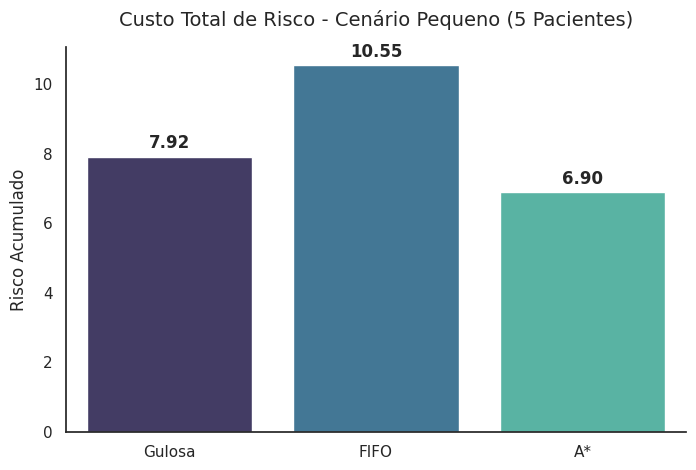

In [ ]:
'''GRÁFICO 1: CENÁRIO PEQUENO (5 Pacientes)'''

'''Criando um DataFrame rápido para o Seaborn consumir nativamente'''
dados_peq = pd.DataFrame({
    'Estratégia': ['Gulosa', 'FIFO', 'A*'],
    'Custo': [custo_gulosa, custo_fifo, custo_a_estrela]
})

plt.figure(figsize=(8, 5))

ax1 = sns.barplot(
    data=dados_peq,
    x='Estratégia',
    y='Custo',
    hue='Estratégia',
    palette='mako',
    legend=False
)

'''Adicionando os rótulos nas barras'''
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.2f', padding=3, fontweight='bold')

plt.title('Custo Total de Risco - Cenário Pequeno (5 Pacientes)', fontsize=14, pad=15)
plt.ylabel('Risco Acumulado', fontsize=12)
plt.xlabel('')
sns.despine()
plt.show()



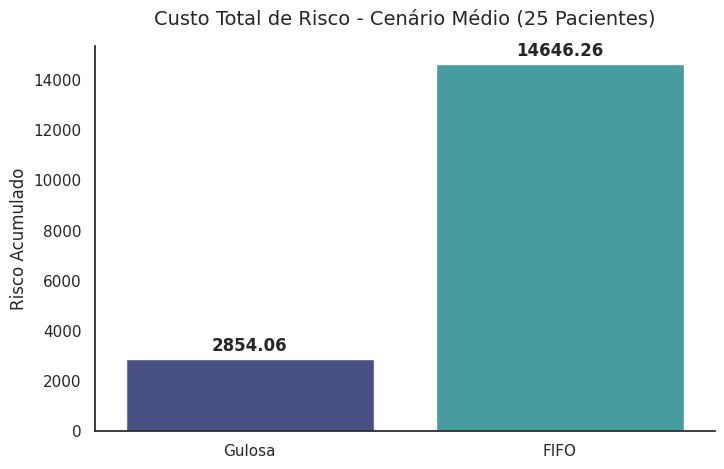

In [ ]:
'''GRÁFICO 2: CENÁRIO MÉDIO (25 Pacientes)'''

dados_med = pd.DataFrame({
    'Estratégia': ['Gulosa', 'FIFO'],
    'Custo': [custo_gulosa_medio, custo_fifo_medio]
})

plt.figure(figsize=(8, 5))

ax2 = sns.barplot(
    data=dados_med,
    x='Estratégia',
    y='Custo',
    hue='Estratégia',
    palette='mako',
    legend=False
)

'''Adicionando os rótulos nas barras'''
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.2f', padding=3, fontweight='bold')

plt.title('Custo Total de Risco - Cenário Médio (25 Pacientes)', fontsize=14, pad=15)
plt.ylabel('Risco Acumulado', fontsize=12)
plt.xlabel('')
sns.despine()
plt.show()